In [116]:
# "Given a text input, classify it into one of 6 emotions (sadness, joy, love, anger, fear, surprise) using supervised machine learning."
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


In [117]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bhavikjikadara/emotions-dataset/emotions.csv


In [118]:
df = pd.read_csv('/kaggle/input/datasets/bhavikjikadara/emotions-dataset/emotions.csv')

df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [119]:
# 0 - sadness
# 1 - joy
# 2 - love
# 3 - anger
# 4 - fear
# 5 - surprise

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB


In [121]:
print(df.shape)
print(df.dtypes)

(416809, 2)
text     object
label     int64
dtype: object


In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

emotion_map= {
    0 : 'sadness',
1 : 'joy',
2 : 'love',
3 : 'anger',
4 : 'fear',
5 : 'surprise'
}

df['emotion'] = df['label'].map(emotion_map)
print(df['emotion'].value_counts())
print()
print(df['emotion'].value_counts(normalize ='True').round(3)*100)

emotion
joy         141067
sadness     121187
anger        57317
fear         47712
love         34554
surprise     14972
Name: count, dtype: int64

emotion
joy         33.8
sadness     29.1
anger       13.8
fear        11.4
love         8.3
surprise     3.6
Name: proportion, dtype: float64


/tmp/ipykernel_58/2488541262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'emotion',


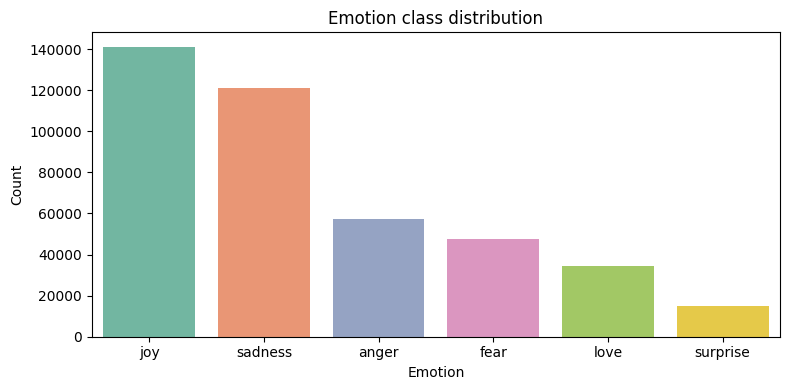

In [123]:
plt.figure(figsize= (8,4))
sns.countplot(data = df, x = 'emotion',
             order = df['emotion'].value_counts().index,
             palette='Set2')
plt.title('Emotion class distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [124]:
for emotion in emotion_map.values():
    print(f"{emotion.upper()}")
    samples = df[df['emotion']==emotion]['text'].sample(3,random_state=42)
    for i, text in enumerate (samples,1):
        print(f"{i}.{text}")

SADNESS
1.ive learned to surround myself with women who lift me up and leave me feeling nurtured rather than drained
2.i already feel crappy because of this and you being upset at me or the situation doesnt help
3.i feel like i have lost mourned and moved past the tears in this relationship
JOY
1.i made nico promise to run away screaming if i ever mention floating the dirty devil at anything less than cfs again although i feel it would be safe at cfs or so and i have floated it at a steady cfs without much problem
2.i want to feel as carefree as i did back then
3.i often feel i want to do what i can to cure these many talented and lovely authors spot readers on their books
LOVE
1.i know how that feels hermione said in a surprisingly sympathetic voice
2.i feel lovely encoding utf locale en isprivate false ismobile false mobileclass languagedirection ltr feedlinks link rel alternate type application atom xml title ri t ch styles
3.i was actually just feeling a little nostalgic and though

In [125]:
df['text_length']= df['text'].apply(len)
df['word_count']= df['text'].apply(lambda x:len(x.split()))

print(df[['text_length','word_count']].describe().round(1))
print()
print("Per-emotion avg words:")
print(df.groupby('emotion')['word_count'].mean().round(1).sort_values())

       text_length  word_count
count     416809.0    416809.0
mean          97.0        19.2
std           56.2        11.1
min            2.0         1.0
25%           54.0        11.0
50%           86.0        17.0
75%          128.0        25.0
max          830.0       178.0

Per-emotion avg words:
emotion
sadness     18.5
anger       19.0
fear        19.0
joy         19.5
surprise    19.7
love        20.8
Name: word_count, dtype: float64


/tmp/ipykernel_58/2992395.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x='emotion', y='word_count',


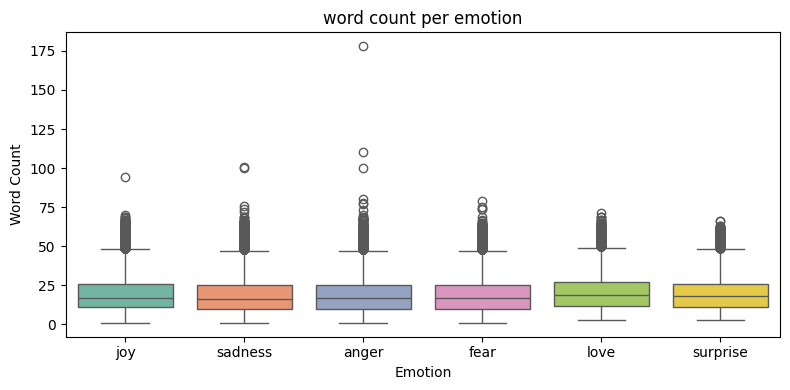

In [126]:
plt.figure(figsize=(8,4))
sns.boxplot(data = df, x='emotion', y='word_count',
           order = df['emotion'].value_counts().index,
           palette ='Set2')
plt.title('word count per emotion')
plt.xlabel('Emotion')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

In [127]:
print('Missing values')
print(df[['text','label']].isnull().sum())

print('duplicate rows:', df.duplicated().sum())
print('Unique labels:', sorted(df['label'].unique()))


Missing values
text     0
label    0
dtype: int64
duplicate rows: 686
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [128]:
# Step 1: pehle duplicates hata do
df = df.drop_duplicates(subset=['text'])

print(f"After removing duplicates: {df.shape[0]} rows")
print(f"Removed: 686 rows")

After removing duplicates: 393822 rows
Removed: 686 rows


Now - Text Preprocessing and Train - test split

In [129]:
import nltk
import os

# Kaggle stores NLTK data here
nltk.data.path.append('/usr/share/nltk_data')
nltk.data.path.append('/usr/local/share/nltk_data')
nltk.data.path.append('/root/nltk_data')

# Now import stopwords normally
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [130]:
import re
import pandas as pd


def preprocessing(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+','',text)
    text = re.sub(r'[^a-z\s]','',text)
    tokens= text.split()   #break in words
    keep = {'not', 'no', 'never', 'nor', 'neither'}
    tokens = [w for w in tokens if (w not in stop_words or w in keep) and len(w) > 1]
    return ' '.join(tokens)
    

In [131]:
df['clean_text'] = df['text'].apply(preprocessing)
print('orginal:', df['text'].iloc[0])
print('cleaned:', df['clean_text'].iloc[0])

orginal: i just feel really helpless and heavy hearted
cleaned: feel really helpless heavy hearted


In [132]:
empty = df[df['clean_text'].str.strip()=='']
print (f"empty texts after cleaning: {len(empty)}") # remove empty strings

if len(empty)>0:
    df = df[df['clean_text'].str.strip() !='']
    print(f"removed {len(empty)} empty rows")

empty texts after cleaning: 9
removed 9 empty rows


In [133]:
# now train-test split 
from sklearn.model_selection import train_test_split
x=df['clean_text']
y = df['label']
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state = 42, stratify= y)

In [134]:
print(f"train:{len(x_train)} | test: {len(x_test)}")

train:315050 | test: 78763


In [135]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 10000, ngram_range=(1, 2))
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

print("train matrix:", x_train_tfidf.shape)
print("test matrix:", x_test_tfidf.shape) 

train matrix: (315050, 10000)
test matrix: (78763, 10000)


In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [137]:
# x = df['text']
# y = df['label']

In [138]:
model= LogisticRegression(
    max_iter =1000,
    C=1.0,
    solver='lbfgs',
    multi_class='auto',
    random_state=42
)
model.fit(x_train_tfidf, y_train)
print('Model training done')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model training done


In [139]:
y_pred = model.predict(x_test_tfidf)

acc= accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}({acc*100:.1f}%)\n")

print(classification_report(
    y_test, y_pred, target_names=list(emotion_map.values())
))

Test Accuracy: 0.9467(94.7%)

              precision    recall  f1-score   support

     sadness       0.96      0.97      0.97     23702
         joy       0.95      0.97      0.96     27006
        love       0.90      0.87      0.89      5893
       anger       0.95      0.94      0.94     10955
        fear       0.92      0.91      0.92      8726
    surprise       0.88      0.83      0.86      2481

    accuracy                           0.95     78763
   macro avg       0.93      0.92      0.92     78763
weighted avg       0.95      0.95      0.95     78763



In [147]:
def predict_emotion(text):
    cleaned = preprocessing(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    proba= model.predict_proba(vec)[0]
    emotion = emotion_map[pred]
    confidence = proba[pred]*100
    print(f"Emotion:{emotion}")
    print(f"Confidence: {confidence:.1f}%")
    for i,p in enumerate(proba):
        print(f"  {emotion_map[i]:<10} {p*100:.1f}%")

predict_emotion("not happy")

Emotion:joy
Confidence: 84.8%
  sadness    6.5%
  joy        84.8%
  love       1.3%
  anger      4.2%
  fear       2.3%
  surprise   0.8%


In [146]:
# Kaggle notebook mein run karo
test = ["Not in the mood to talk today"]
cleaned = preprocessing(test[0])
print("After preprocess:", cleaned)
# Output: "mood talk today" — "not" gayab ho gaya!

After preprocess: not happy


In [142]:
import pickle
with open('emotion_model.pkl','wb') as f:
    pickle.dump(model,f)

with open('vectorizer.pkl','wb') as f:
    pickle.dump(vectorizer, f)

print("Saved: emotion_model.pkl")
print("Saved: vectorizer.pkl")


Saved: emotion_model.pkl
Saved: vectorizer.pkl
